In [ ]:
 #Type Data Visual

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file

In [13]:
df = pd.read_csv("results.csv")

In [19]:
df.head()
df.shape

(1003, 24)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   _id                    1003 non-null   object 
 1   isPb                   40 non-null     object 
 2   wpm                    1003 non-null   float64
 3   acc                    1003 non-null   float64
 4   rawWpm                 1003 non-null   float64
 5   consistency            1003 non-null   float64
 6   charStats              1003 non-null   object 
 7   mode                   1003 non-null   object 
 8   mode2                  1003 non-null   object 
 9   quoteLength            1000 non-null   float64
 10  restartCount           1003 non-null   int64  
 11  testDuration           1003 non-null   float64
 12  afkDuration            1003 non-null   int64  
 13  incompleteTestSeconds  1003 non-null   float64
 14  punctuation            1003 non-null   bool   
 15  numb

In [23]:
df.head()

,_id,isPb,wpm,acc,rawWpm,consistency,charStats,mode,mode2,quoteLength,...,punctuation,numbers,language,funbox,difficulty,lazyMode,blindMode,bailedOut,tags,timestamp
0,68a0ade19b82a8cb33814677,True,49.89,96.15,49.89,74.70,48;0;0;0,words,10,NaN,...,False,False,hinglish,NaN,normal,False,False,False,NaN,1755360737165
1,68a0acf89b82a8cb33813e96,NaN,46.13,86.49,46.13,59.92,559;0;0;0,words,100,NaN,...,False,False,english_1k,NaN,normal,False,False,False,NaN,1755360503220
2,68a0ac499b82a8cb338138d6,NaN,81.91,95.42,85.97,76.01,121;2;0;0,words,25,NaN,...,False,False,english,NaN,normal,False,False,False,NaN,1755360290609
3,689c75284cec7cefb6357deb,NaN,71.69,95.56,71.69,56.29,129;0;0;0,words,25,-1.0,...,False,False,english,NaN,normal,False,False,False,NaN,1755084072000
4,689c750f4cec7cefb6357d25,NaN,51.31,86.71,56.61,65.56,116;3;0;0,words,25,-1.0,...,False,False,english,NaN,normal,False,False,False,NaN,1755084047000


In [25]:
df = df[['charStats','wpm','rawWpm','acc','mode','mode2']]

In [27]:
df.head()

,charStats,wpm,rawWpm,acc,mode,mode2
0,48;0;0;0,49.89,49.89,96.15,words,10
1,559;0;0;0,46.13,46.13,86.49,words,100
2,121;2;0;0,81.91,85.97,95.42,words,25
3,129;0;0;0,71.69,71.69,95.56,words,25
4,116;3;0;0,51.31,56.61,86.71,words,25


In [29]:
df[['correctChars','incorrectChars','extraChars','missedChars']]=df['charStats'].str.split(';',expand=True)

In [31]:
df.head()

,charStats,wpm,rawWpm,acc,mode,mode2,correctChars,incorrectChars,extraChars,missedChars
0,48;0;0;0,49.89,49.89,96.15,words,10,48,0,0,0
1,559;0;0;0,46.13,46.13,86.49,words,100,559,0,0,0
2,121;2;0;0,81.91,85.97,95.42,words,25,121,2,0,0
3,129;0;0;0,71.69,71.69,95.56,words,25,129,0,0,0
4,116;3;0;0,51.31,56.61,86.71,words,25,116,3,0,0


In [33]:
df['wpm'].groupby(df['mode']).mean()

mode
time     63.441692
words    64.711561
zen      36.250000
Name: wpm, dtype: float64

In [35]:
df[['correctChars','incorrectChars','extraChars','missedChars']] = df[['correctChars','incorrectChars','extraChars','missedChars']].apply(pd.to_numeric)

In [37]:
df.head()

,charStats,wpm,rawWpm,acc,mode,mode2,correctChars,incorrectChars,extraChars,missedChars
0,48;0;0;0,49.89,49.89,96.15,words,10,48,0,0,0
1,559;0;0;0,46.13,46.13,86.49,words,100,559,0,0,0
2,121;2;0;0,81.91,85.97,95.42,words,25,121,2,0,0
3,129;0;0;0,71.69,71.69,95.56,words,25,129,0,0,0
4,116;3;0;0,51.31,56.61,86.71,words,25,116,3,0,0


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

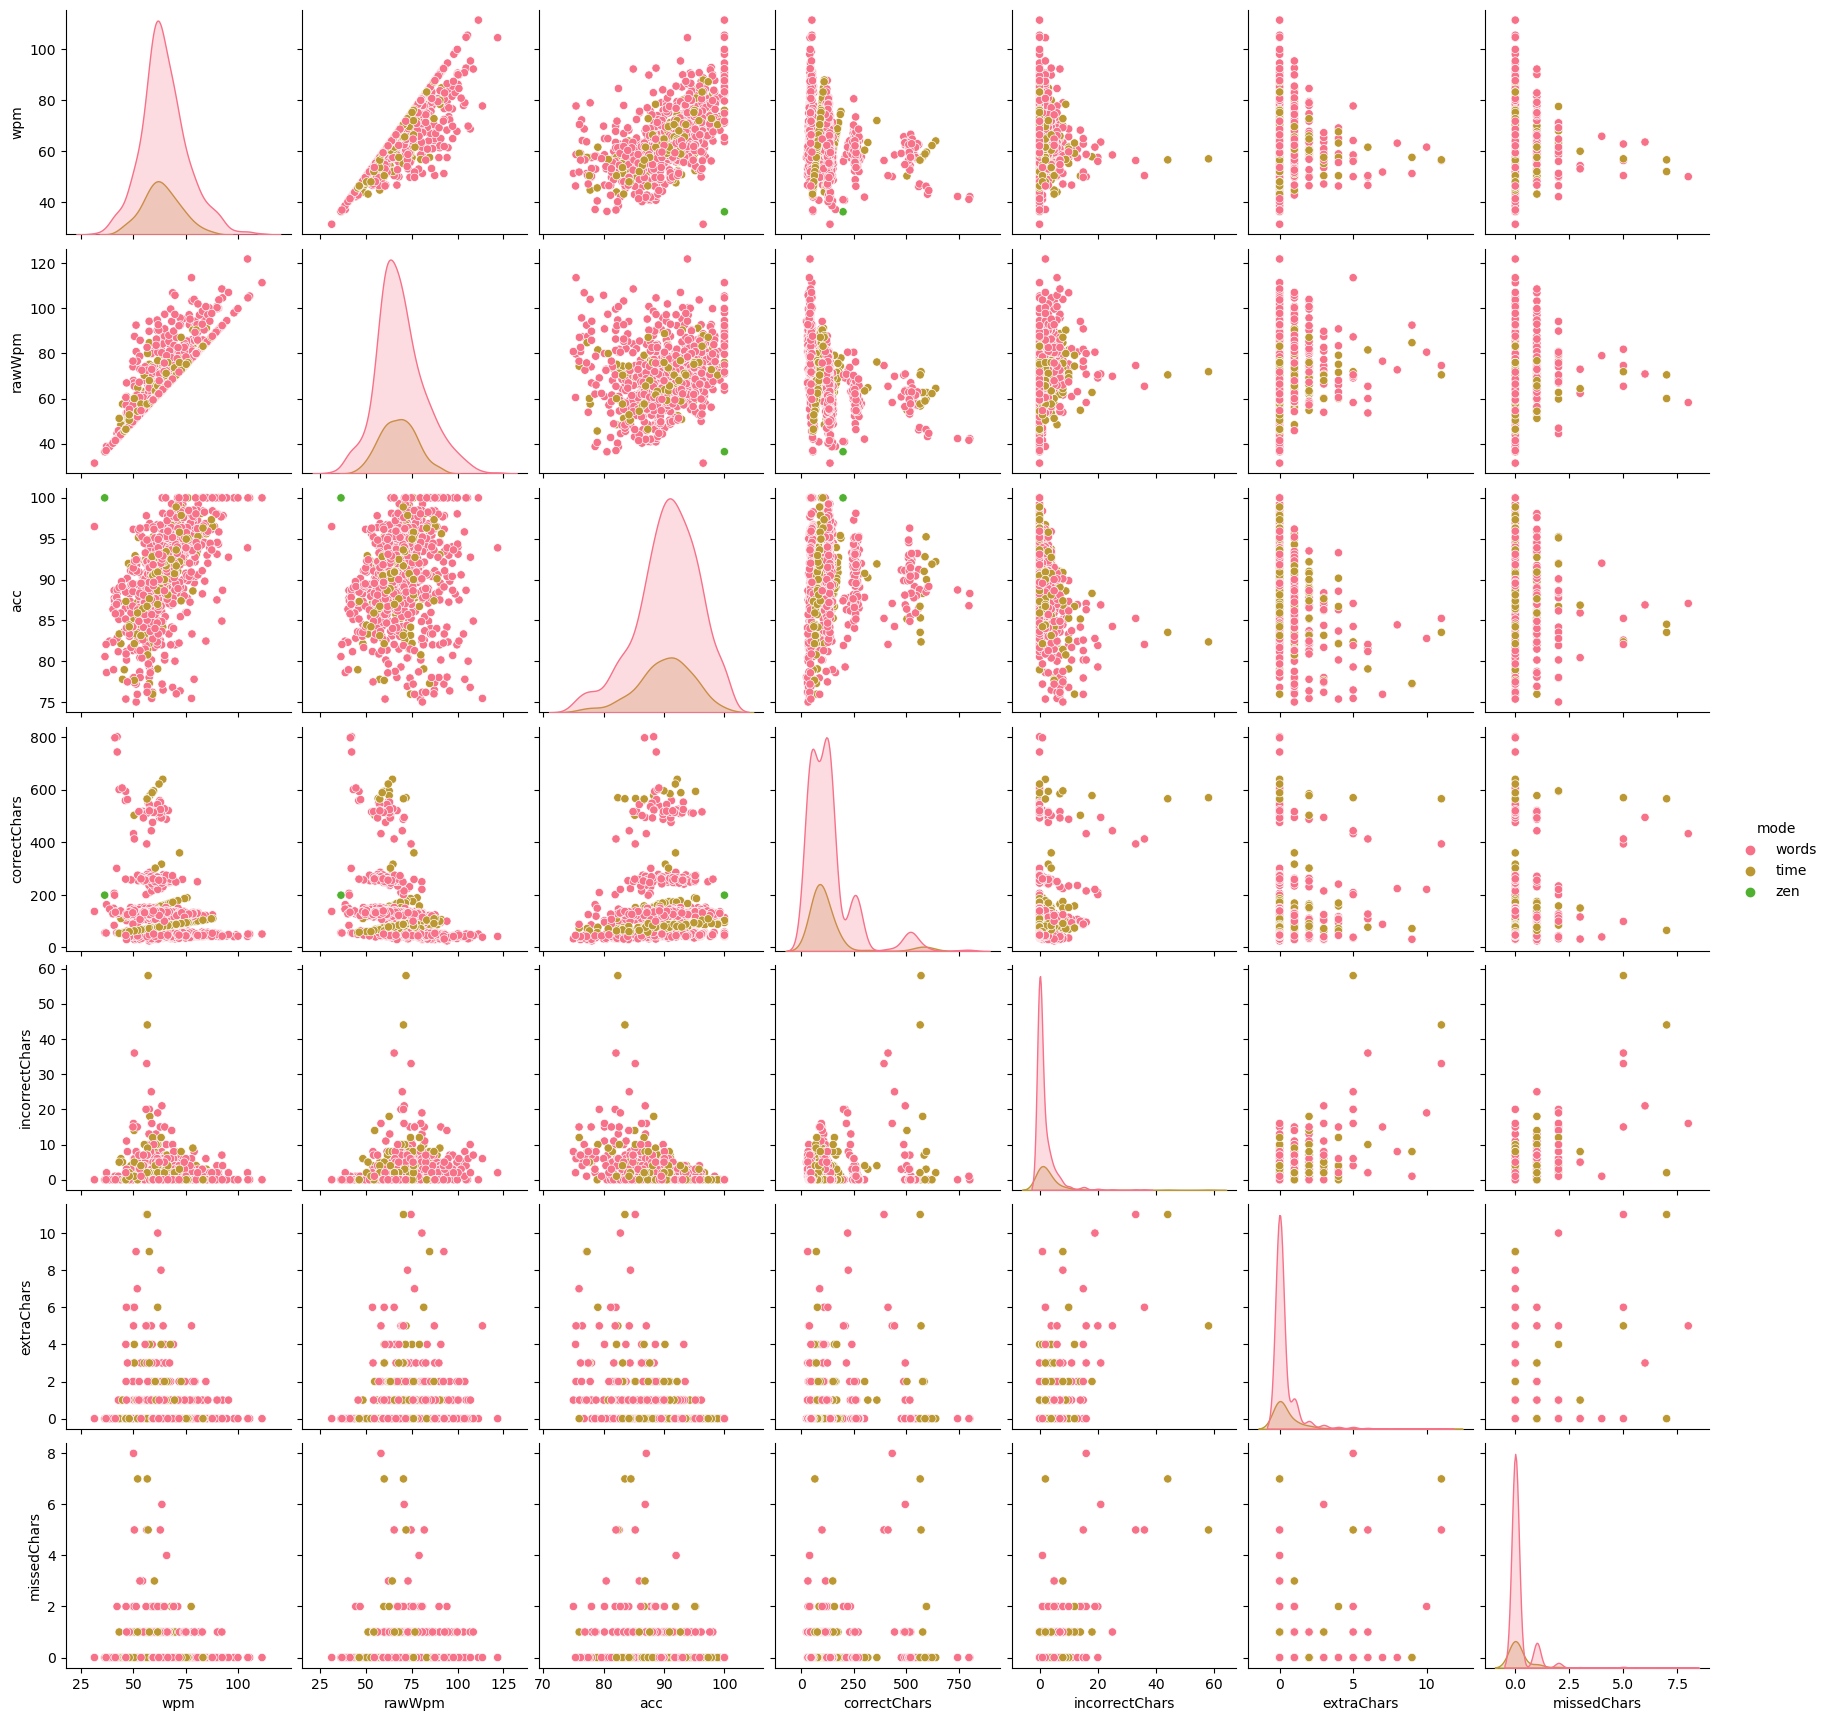

In [43]:
sns.set_palette('husl')
sns.pairplot(df,hue="mode",diag_kind="kde")
plt.show()

C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\praka\AppData\Local\Temp\ipykernel_30532\1260971956.py:2: UserWarning: Dataset has 0 variance; skip

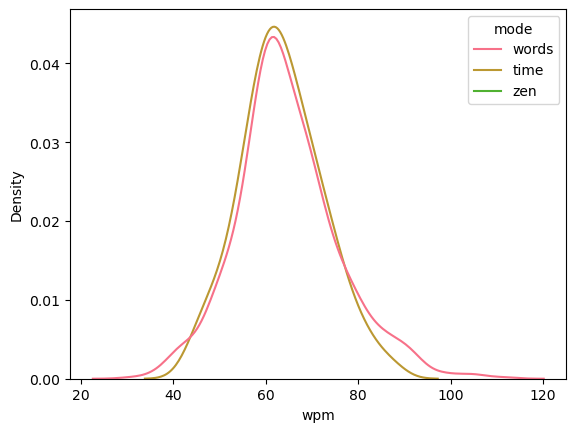

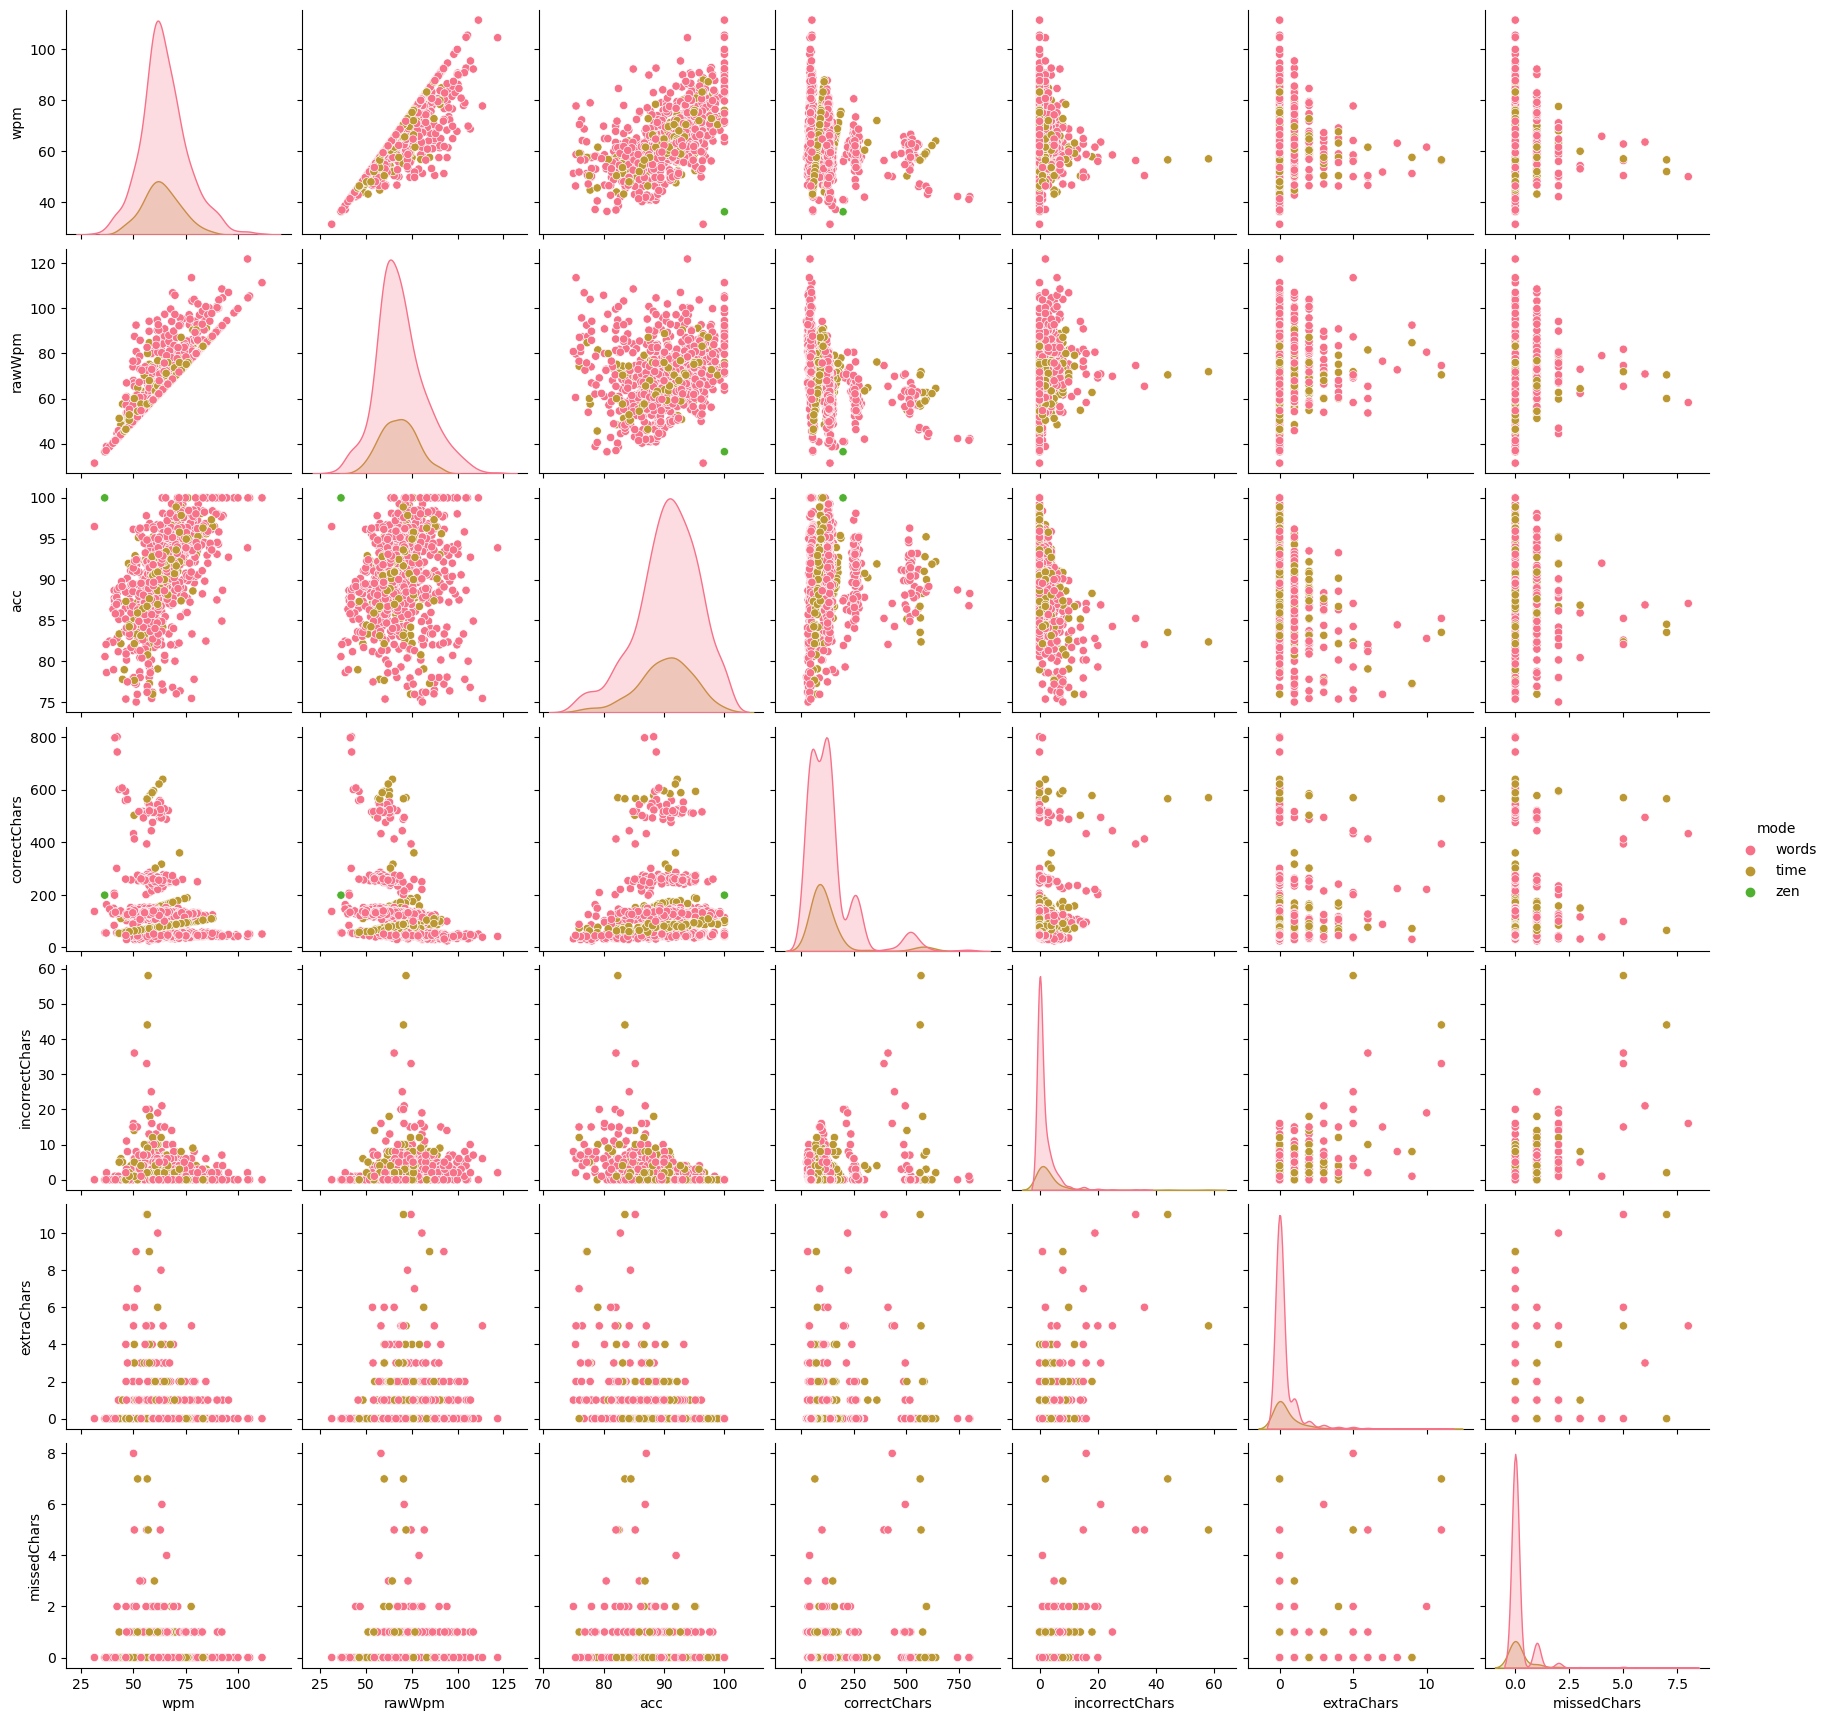

In [45]:
import seaborn as sns
sns.kdeplot(data=df, x='wpm', hue='mode', common_norm=False)
# or pairplot with KDE on diagonals:
sns.pairplot(df, hue='mode', diag_kind='kde')


C:\Users\praka\AppData\Local\Temp\ipykernel_30532\1100696113.py:4: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=df[['wpm','rawWpm','acc']],palette="magma",linewidth=2,markers='o',dashes=False)
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


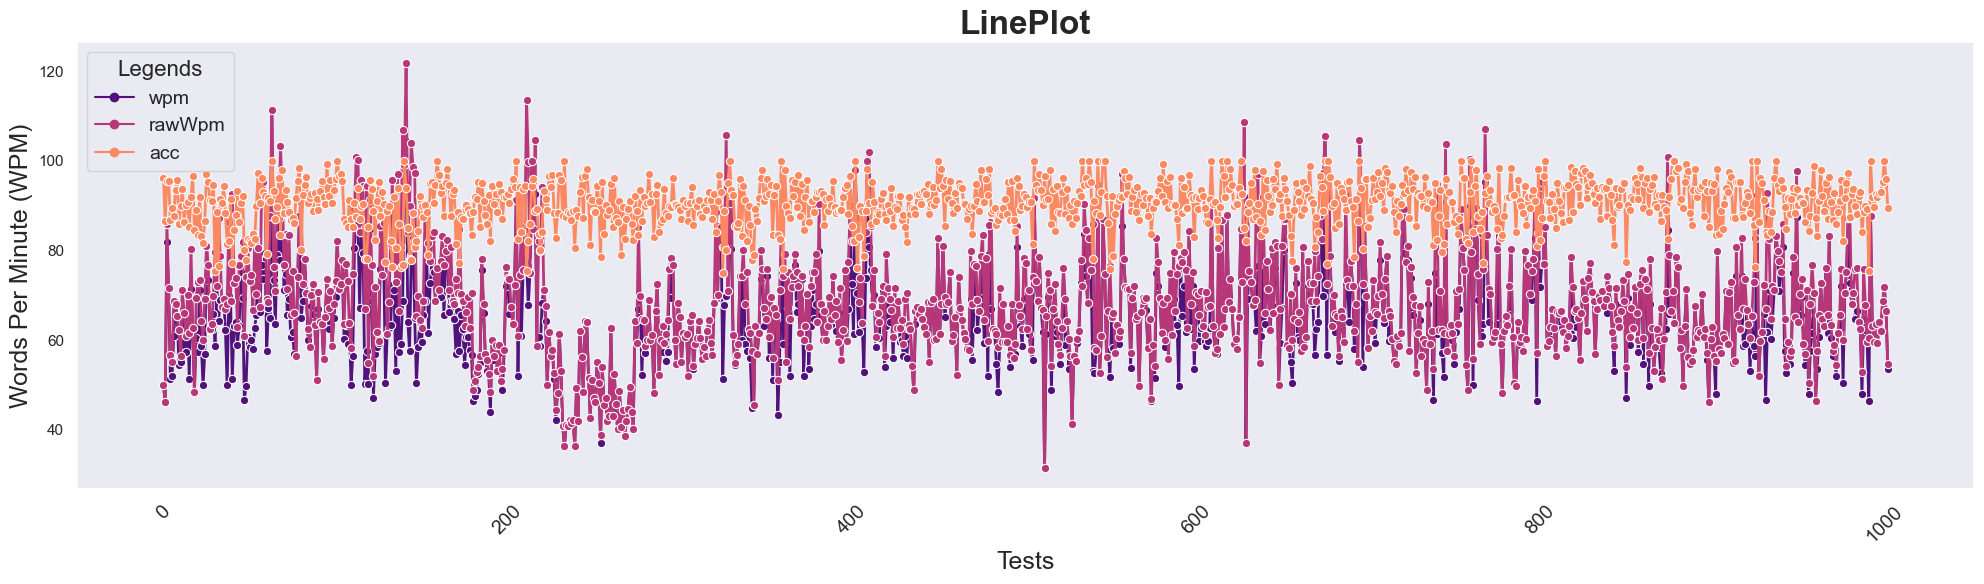

In [49]:
sns.set_style("dark")
sns.set_context("notebook")
plt.figure(figsize=(20,6))
sns.lineplot(data=df[['wpm','rawWpm','acc']],palette="magma",linewidth=2,markers='o',dashes=False)
plt.title("LinePlot", fontsize=24, weight='bold')
plt.xlabel("Tests", fontsize=18) and plt.ylabel("Words Per Minute (WPM)", fontsize=18)
plt.xticks(rotation=45, fontsize=14)
plt.legend(title='Legends', fontsize=14, title_fontsize='16')
plt.tight_layout()
plt.show()

C:\Users\praka\AppData\Local\Temp\ipykernel_30532\2888462327.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['missedChars']/max(df['missedChars']), color=colors[2], label='Missed Characters', hist=False, kde=True,
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\AppData\Local\Temp\ipykernel_30532\2888462327.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v

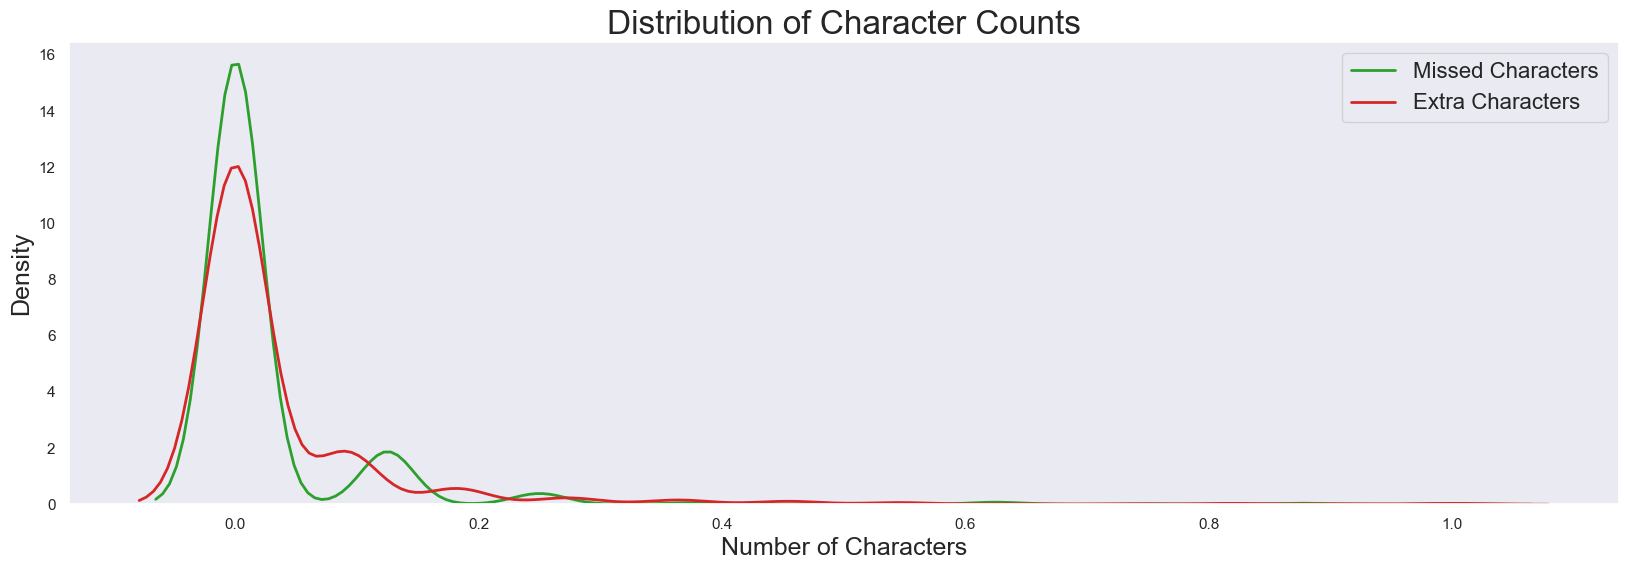

In [57]:
sns.set_style("dark")  
sns.set_context("notebook")  

# Create the figure  
plt.figure(figsize=(20, 6))  

# Customize the color palette  
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  
colors = sns.color_palette(palette)  

sns.distplot(df['missedChars']/max(df['missedChars']), color=colors[2], label='Missed Characters', hist=False, kde=True,   
             kde_kws={'linewidth': 2, 'color': colors[2]}) 
             
sns.distplot(df['extraChars']/max(df['extraChars']), color=colors[3], label='Extra Characters', hist=False, kde=True,   
             kde_kws={'linewidth': 2, 'color': colors[3]})  

# Add titles and labels  
plt.title('Distribution of Character Counts', fontsize=24)  
plt.xlabel('Number of Characters', fontsize=18)  
plt.ylabel('Density', fontsize=18)  

# Add a legend  
plt.legend(fontsize=16)  

# Show the plot 
plt.show()

C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


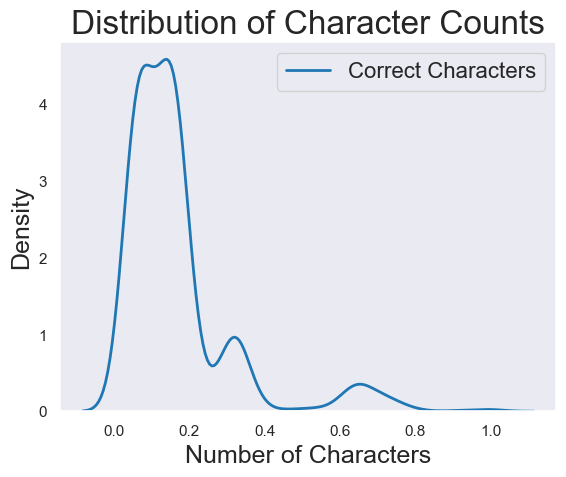

In [53]:
sns.kdeplot(
    df['correctChars'] / max(df['correctChars']),
    color=colors[0],
    label='Correct Characters',
    linewidth=2
)
# Add titles and labels  
plt.title('Distribution of Character Counts', fontsize=24)  
plt.xlabel('Number of Characters', fontsize=18)  
plt.ylabel('Density', fontsize=18)  

# Add a legend  
plt.legend(fontsize=16)  

# Show the plot 
plt.show()

C:\Users\praka\AppData\Local\Temp\ipykernel_30532\4186626213.py:8: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=df[['missedChars','incorrectChars']], palette="magma", linewidth=2, markers='o', dashes=False)
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


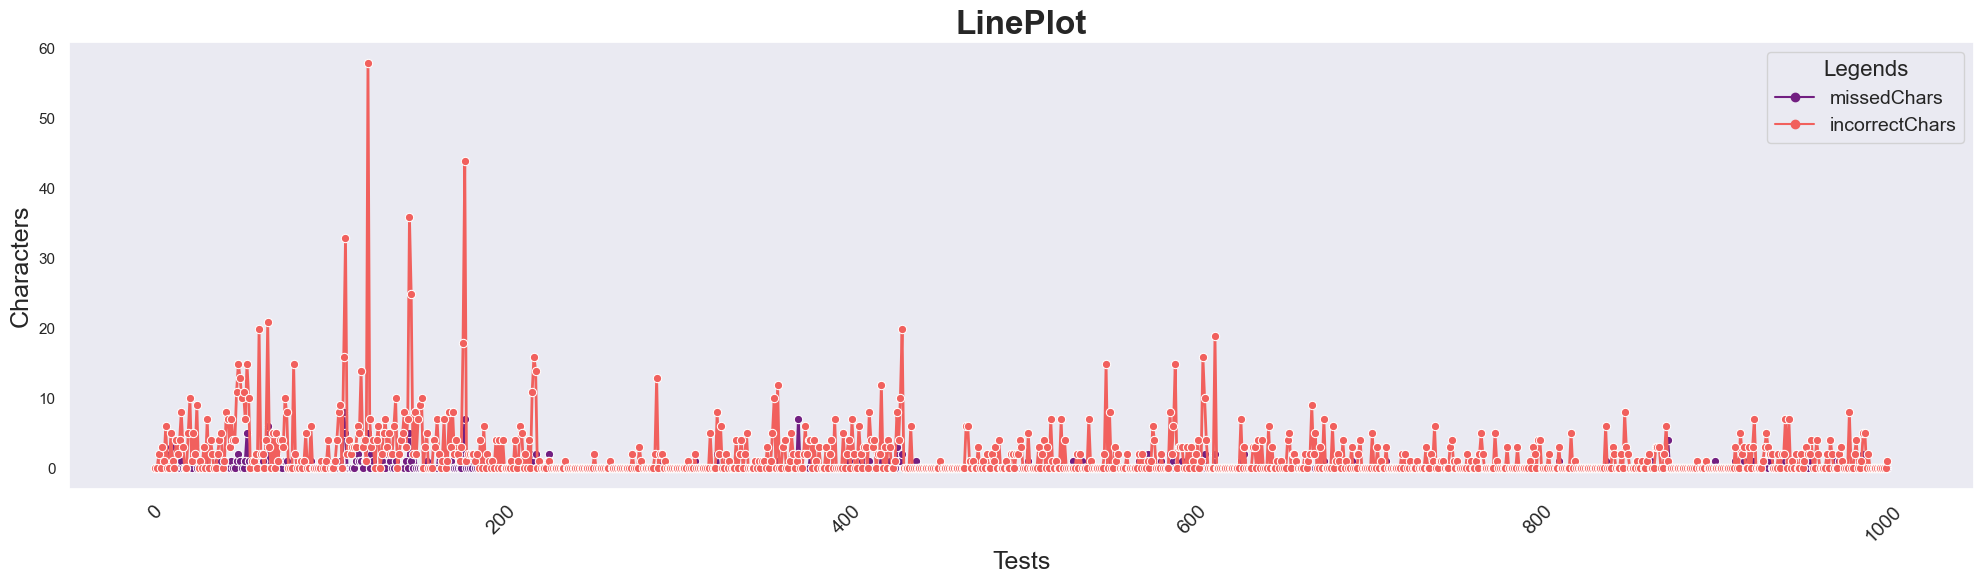

In [59]:
sns.set_style("dark")
sns.set_context("notebook")

# Create the figure
plt.figure(figsize=(20, 6))

# Create the line plot with improvements
sns.lineplot(data=df[['missedChars','incorrectChars']], palette="magma", linewidth=2, markers='o', dashes=False) 

# Add titles and labels
plt.title("LinePlot", fontsize=24, weight='bold')
plt.xlabel("Tests", fontsize=18)
plt.ylabel("Characters", fontsize=18)

# Rotate x-ticks for better readability if necessary
plt.xticks(rotation=45, fontsize=14)

# Add a legend
plt.legend(title='Legends', fontsize=14, title_fontsize='16')

# Optional: Use tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [69]:
new_df = df['wpm'].groupby(df['mode']).count().reset_index()

In [67]:
new_df

mode
time     195
words    807
zen        1
Name: wpm, dtype: int64

In [71]:
new_df

,mode,wpm
0,time,195
1,words,807
2,zen,1


In [73]:
new_df = df.groupby('mode')['wpm'].count().reset_index(name='count')

In [75]:
new_df

,mode,count
0,time,195
1,words,807
2,zen,1


Text(0.5, 1.0, 'Count of Tests by Mode')

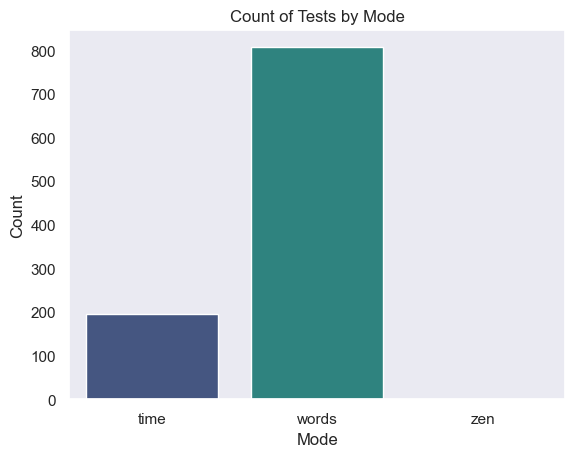

In [77]:
grouped_data = df['wpm'].groupby(df['mode']).count().reset_index()
grouped_data.columns = ['mode', 'count']  # Rename columns for clarity

# Plot using seaborn
sns.barplot(x='mode', y='count', data=grouped_data, palette='viridis')

# Add labels and title
plt.xlabel('Mode')
plt.ylabel('Count')
plt.title('Count of Tests by Mode')

<Axes: xlabel='wpm', ylabel='acc'>

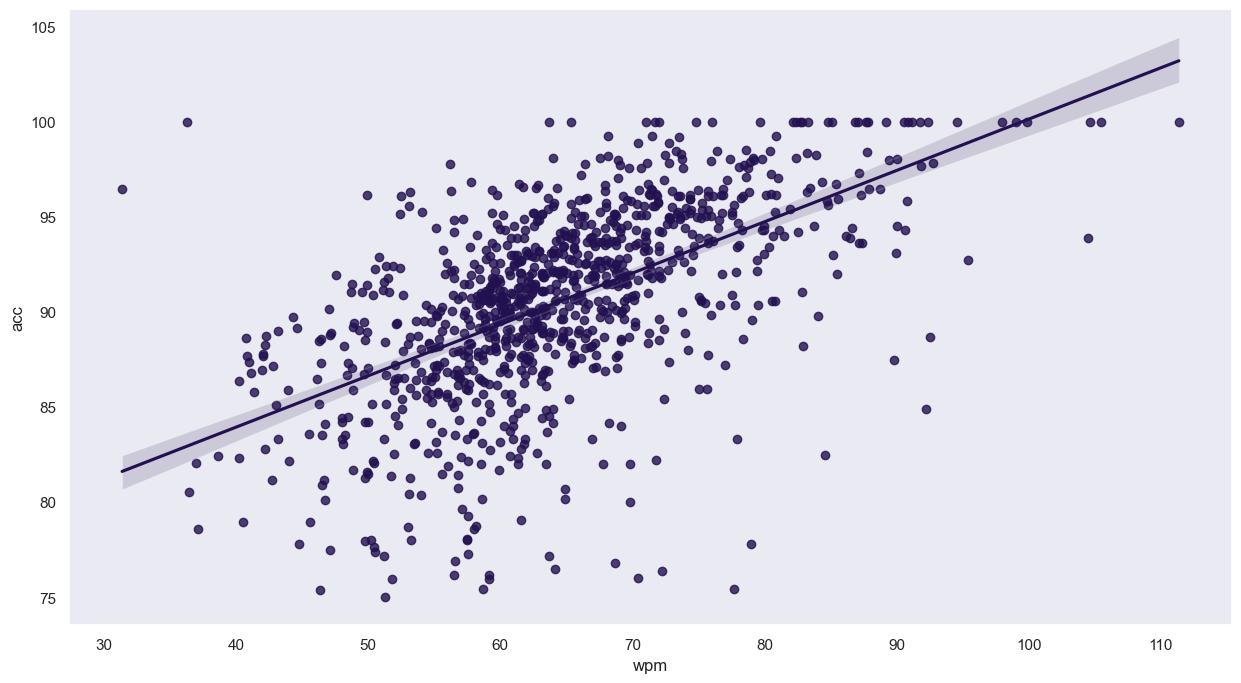

In [93]:
plt.figure(figsize=(15,8))
sns.set_style('dark')
sns.set_palette('magma')
sns.regplot(x=df['wpm'],y=df['acc'])

<Axes: xlabel='wpm', ylabel='acc'>

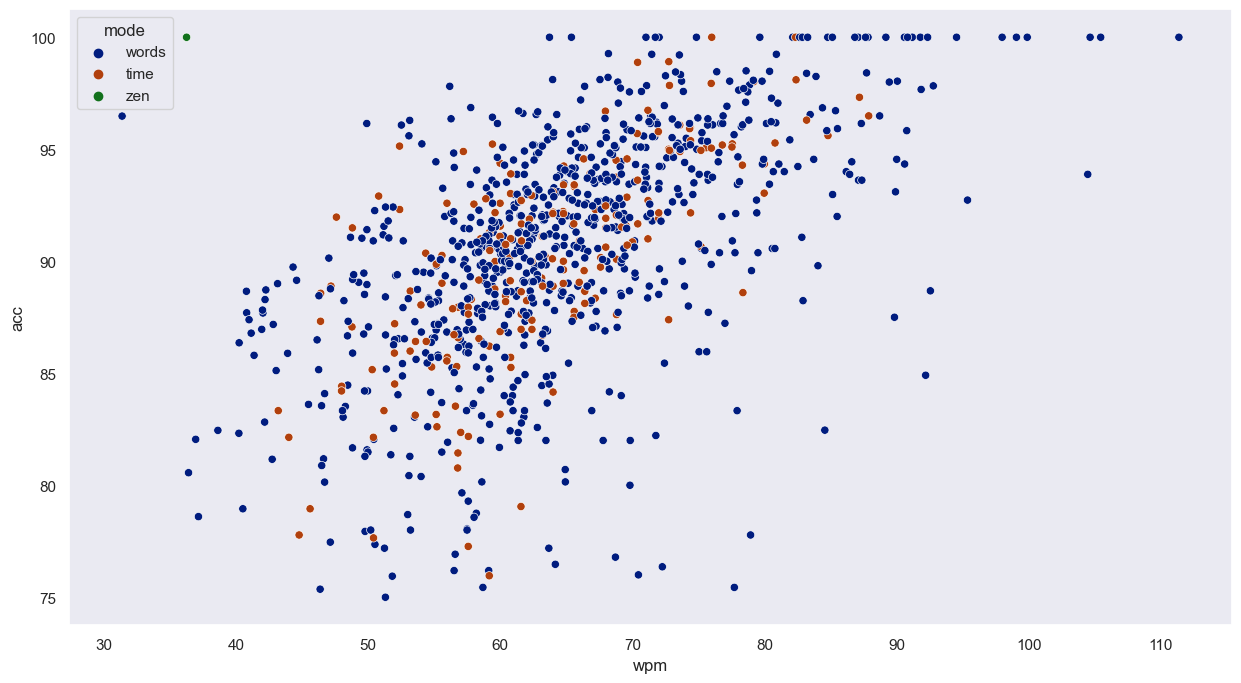

In [95]:
plt.figure(figsize=(15,8))
sns.set_style('dark')
sns.scatterplot(x=df['wpm'],y=df['acc'],hue=df['mode'],palette='dark')

Text(0.5, 1.0, 'Count of Tests by Mode2')

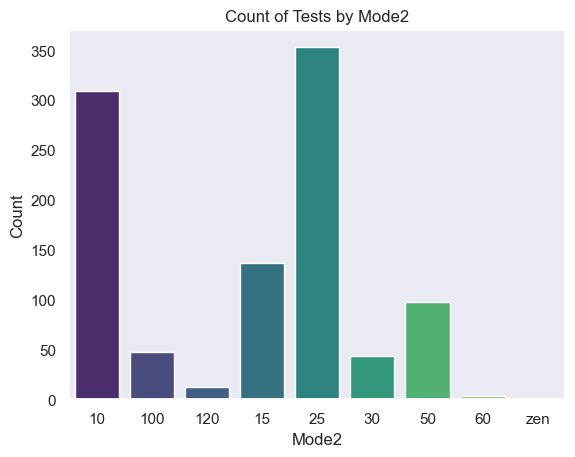

In [97]:
grouped_data2 = df['wpm'].groupby(df['mode2']).count().reset_index()
grouped_data2.columns = ['mode2', 'count']  # Rename columns for clarity

# Plot using seaborn
sns.barplot(x='mode2', y='count', data=grouped_data2, palette='viridis')

# Add labels and title
plt.xlabel('Mode2')
plt.ylabel('Count')
plt.title('Count of Tests by Mode2')

<Axes: xlabel='wpm', ylabel='acc'>

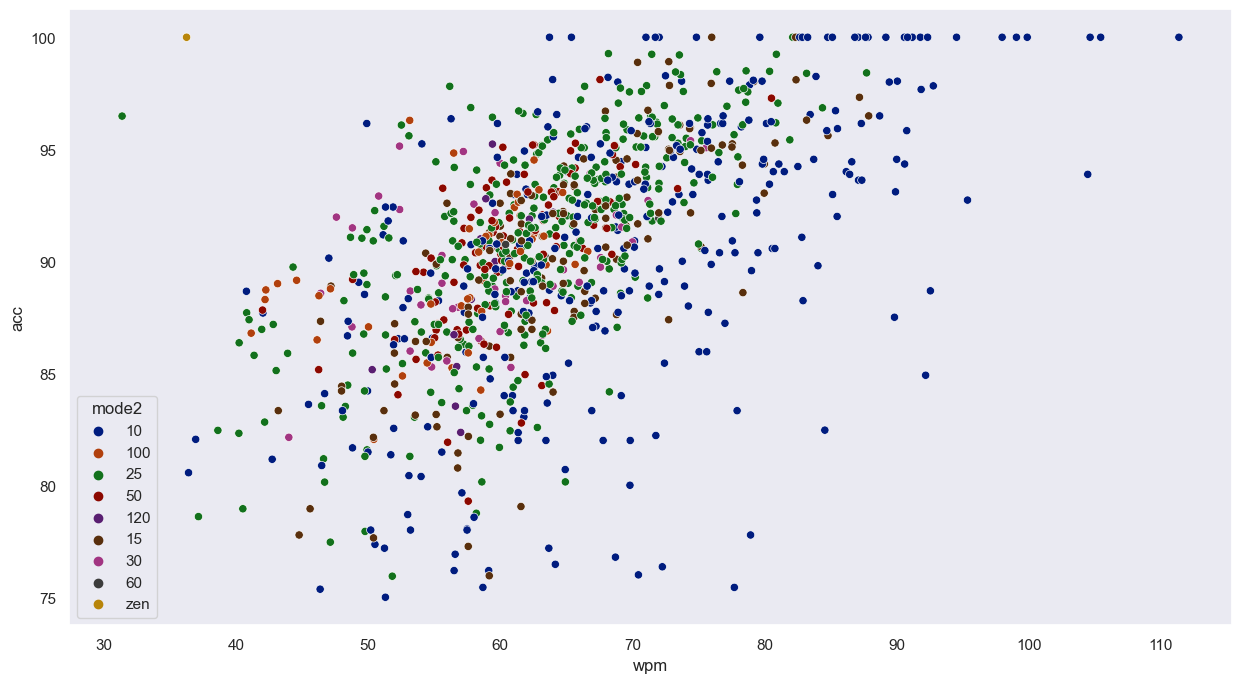

In [99]:
plt.figure(figsize=(15,8))
sns.set_style('dark')
sns.scatterplot(x=df['wpm'],y=df['acc'],hue=df['mode2'],palette='dark')

C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

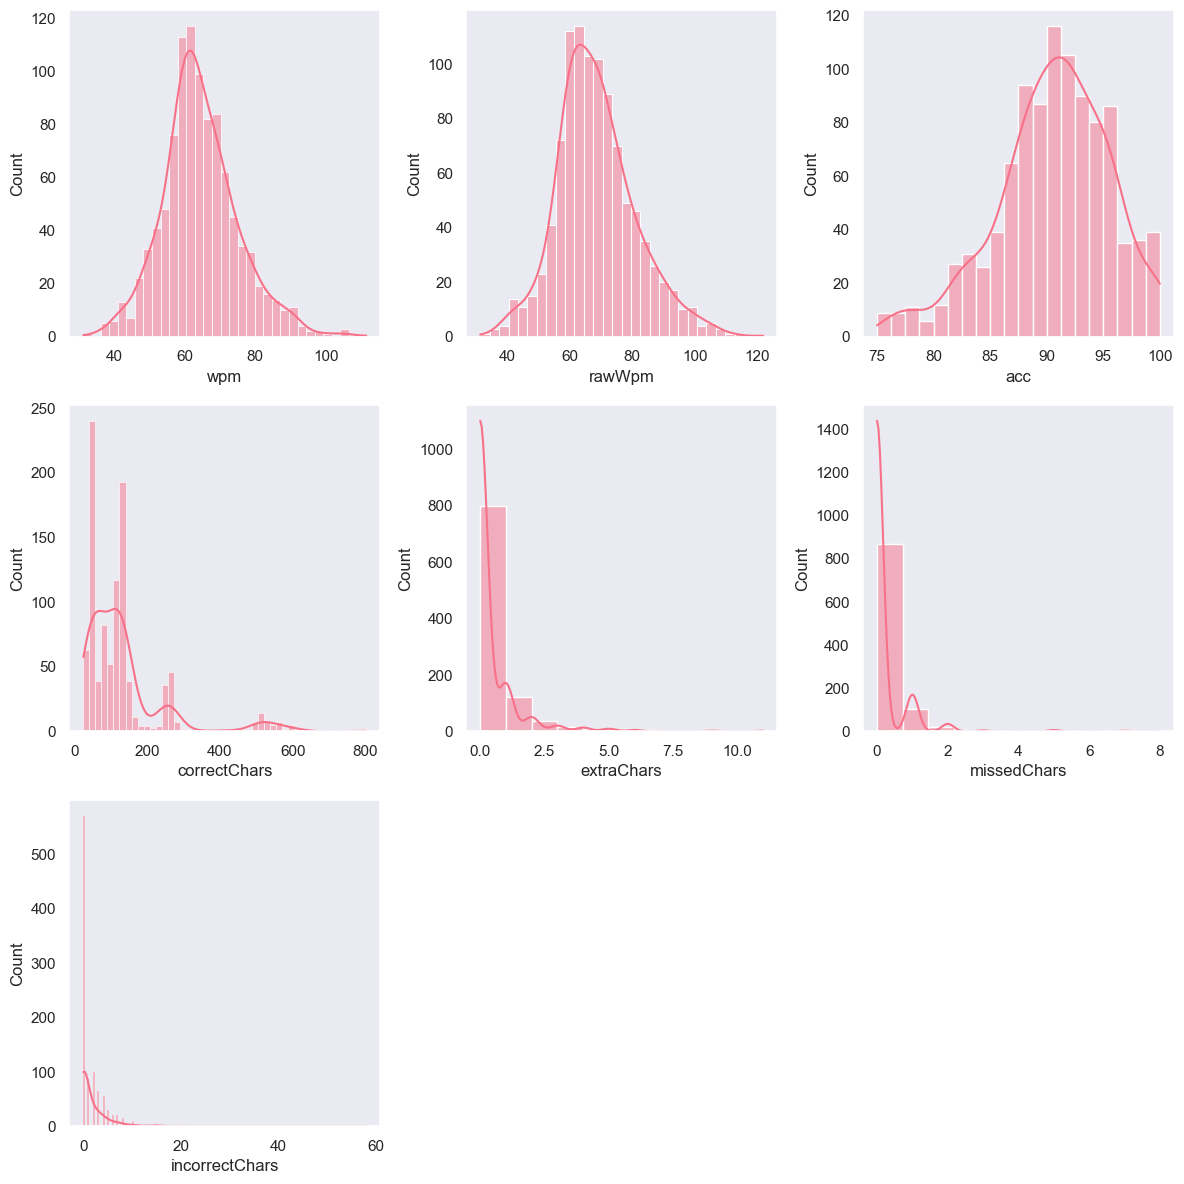

In [101]:
cols = ['wpm','rawWpm','acc','correctChars','extraChars','missedChars','incorrectChars']
plt.figure(figsize=(12,12))
sns.set_palette('husl')

for i in range(len(cols)):
    plt.subplot(3,3,i+1)
    sns.histplot(df[cols[i]],kde=True)
    plt.tight_layout()

C:\Users\praka\AppData\Local\Temp\ipykernel_30532\3153319692.py:5: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.15`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.13.0.

  sns.kdeplot(x=df['wpm']/max(df['wpm']),y=df['rawWpm']/max(df['rawWpm']),fill=True, bw=.15)
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\praka\AppData\Local\Temp\ipykernel_30532\3153319692.py:9: UserWarnin

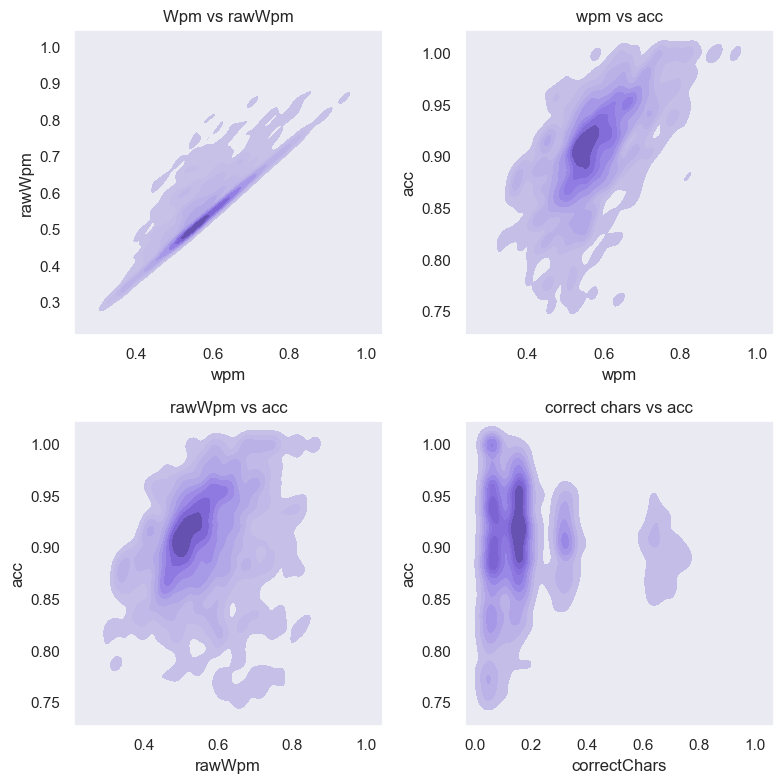

In [103]:
plt.figure(figsize=(8,8))
sns.set_palette('magma')

plt.subplot(2,2,1)
sns.kdeplot(x=df['wpm']/max(df['wpm']),y=df['rawWpm']/max(df['rawWpm']),fill=True, bw=.15)
plt.title("Wpm vs rawWpm")

plt.subplot(2,2,2)
sns.kdeplot(x=df['wpm']/max(df['wpm']),y=df['acc']/max(df['acc']),fill=True, bw=.15)
plt.title("wpm vs acc")

plt.subplot(2,2,3)
sns.kdeplot(x=df['rawWpm']/max(df['rawWpm']),y=df['acc']/max(df['acc']),fill=True, bw=.15)
plt.title("rawWpm vs acc")

plt.subplot(2,2,4)
sns.kdeplot(x=df['correctChars']/max(df['correctChars']),y=df['acc']/max(df['acc']),fill=True, bw=.15)
plt.title("correct chars vs acc")

plt.tight_layout()
plt.show()